In [1]:
# Cài đặt phiên bản thư viện ổn định nhất
!pip install -q datasets==2.19.0 huggingface_hub==0.23.0

import os
import shutil

# Xóa bộ nhớ tạm (cache) bị lỗi cũ
cache_dir = os.path.expanduser("~/.cache/huggingface/datasets")
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir, ignore_errors=True)
    
print("Thiết lập môi trường thành công! Vui lòng bấm Restart Kernel trên thanh công cụ, sau đó chạy ô code tiếp theo.")

Thiết lập môi trường thành công! Vui lòng bấm Restart Kernel trên thanh công cụ, sau đó chạy ô code tiếp theo.


In [2]:
!pip install -q --upgrade dill multiprocess

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.19.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.


In [3]:
from datasets import load_dataset
import pandas as pd

# 1. Tải bộ dữ liệu NER
dataset = load_dataset("wikiann", "vi")

print("1. TỔNG QUAN TẬP DỮ LIỆU:")
print(dataset)
print("-" * 50)

# 2. Lấy danh sách nhãn
label_list = dataset["train"].features["ner_tags"].feature.names
print("2. DANH SÁCH NHÃN THỰC THỂ:")
print(label_list)
print("-" * 50)

# 3. Hiển thị thử câu đầu tiên dưới dạng bảng
sample = dataset['train'][0]
df = pd.DataFrame({
    "Từ vựng (Token)": sample['tokens'],
    "ID Nhãn": sample['ner_tags'],
    "Tên Nhãn (Tag)": [label_list[tag_id] for tag_id in sample['ner_tags']]
})

print("3. DỮ LIỆU MẪU (Câu đầu tiên trong tập Train):")
print(df)

e:\code\NLP_train_Payt\NLP_Project_Tuan16\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 20000/20000 [00:00<00:00, 1056925.71 examples/s]

1. TỔNG QUAN TẬP DỮ LIỆU:
DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 10000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs', 'spans'],
        num_rows: 20000
    })
})
--------------------------------------------------
2. DANH SÁCH NHÃN THỰC THỂ:
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
--------------------------------------------------
3. DỮ LIỆU MẪU (Câu đầu tiên trong tập Train):
  Từ vựng (Token)  ID Nhãn Tên Nhãn (Tag)
0            Đồng        5          B-LOC
1            bằng        6          I-LOC
2            sông        6          I-LOC
3             Cửu        6          I-LOC
4            Long        6          I-LOC


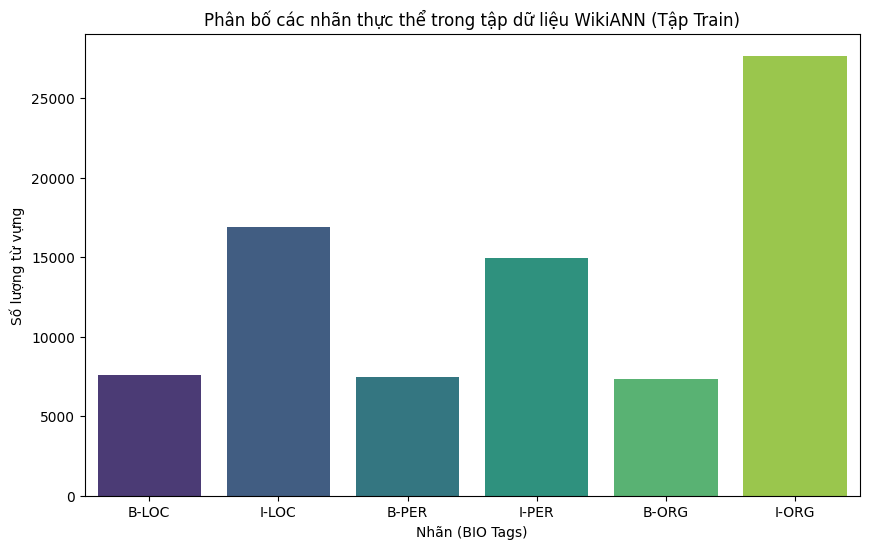

In [4]:
# 1. Cài đặt thư viện vẽ biểu đồ
!pip install -q matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 2. Gom toàn bộ nhãn (tags) của hàng chục ngàn câu trong tập Train lại với nhau
all_tags = []
for tags in dataset['train']['ner_tags']:
    all_tags.extend(tags)

# 3. Dịch ID (số) sang Tên nhãn (chữ) và đếm số lượng
tag_names = [label_list[tag_id] for tag_id in all_tags]
tag_counts = Counter(tag_names)

# 4. Lọc bỏ nhãn 'O' (Outside - chữ bình thường)
# Lý do: Chữ bình thường luôn chiếm hơn 80-90% câu văn. Nếu vẽ chung, cột 'O' sẽ cao chót vót làm bẹp các cột thực thể khác.
entity_counts = {k: v for k, v in tag_counts.items() if k != 'O'}

# 5. Dựng biểu đồ
plt.figure(figsize=(10, 6))
# Sử dụng hue và legend=False để tránh cảnh báo của thư viện seaborn mới
sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()), hue=list(entity_counts.keys()), palette="viridis", legend=False)
plt.title("Phân bố các nhãn thực thể trong tập dữ liệu WikiANN (Tập Train)")
plt.xlabel("Nhãn (BIO Tags)")
plt.ylabel("Số lượng từ vựng")
plt.show()

In [5]:
!pip install transformers torch seqeval

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached huggingface_hub-1.32.0-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached tomli-2.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 2.19.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.


In [6]:
!pip install evaluate

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
  Using cached multiprocess-0.70.18-py310-none-any.whl.metadata (7.5 kB)
  Using cached multiprocess-0.70.17-py310-none-any.whl.metadata (7.2 kB)
  Using cached multiprocess-0.70.16-py310-none-any.whl.metadata (7.2 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached multiprocess-0.70.16-py310-none-any.whl (134 kB)

  Attempting uninstall: dill

    Found existing installation: dill 0.4.1

    Uninstalling dill-0.4.1:

      Successfully uninstalled dill-0.4.1

   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------